# 04 · Fighters, attributes and divisions

Research question: which fighters stand out in volume and efficiency, and how do attributes vary across divisions? Name collisions remain separate by fighter ID. Profile traits are snapshots.

In [1]:
from pathlib import Path
import sys
import io
import pandas as pd
import numpy as np
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'raw').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.data_loader import load_raw, profile_sources, verify_raw, TABLES
from src.pipeline import prepare
from src.analysis import *
from src.visualization import *
def show(figure):
    buffer = io.BytesIO()
    figure.savefig(buffer, format='png', bbox_inches='tight')
    display(Image(data=buffer.getvalue()))
    plt.close(figure)

## Prepare cohort

All rates and records below use the selected UFC window.

In [2]:
data = prepare(save=False)
fights, appearances = cohort(data)
print(f"Cohort: {len(fights):,} fights, {fights.event_id.nunique():,} events, {appearances.fighter_id.nunique():,} fighters")
print(f"Date range: {fights.event_date.min():%Y-%m-%d} to {fights.event_date.max():%Y-%m-%d}")

Cohort: 8,820 fights, 783 events, 2,735 fighters
Date range: 1994-03-11 to 2026-08-08


## Volume versus efficiency

Win rates divide wins by decisive fights. Finish-win rates divide finish wins by all bouts. Require 10 decisive fights for percentage leaderboards.

In [3]:
leaders = fighter_summary(appearances)
display(leaders[['fighter_name','fighter_id','fights','wins','losses','other_results','ko_wins','submission_wins','longest_win_streak_conservative']].head(20))
display(leaders.query('decisive_fights >= 10').nlargest(15,'win_rate')[['fighter_name','decisive_fights','wins','win_rate','finish_win_rate']])

,fighter_name,fighter_id,fights,wins,losses,other_results,ko_wins,submission_wins,longest_win_streak_conservative
2238,Jim Miller,d1941565abf50b16,47,28,18,1,6,14,7
87,Charles Oliveira,07225ba28ae309b6,37,25,11,1,4,17,11
1419,Neil Magny,84b3e7d38f2d2ec5,37,24,13,0,7,3,7
211,Max Holloway,150ff4cc642270b9,33,24,9,0,12,2,13
609,Andrei Arlovski,3738e68d2261e60f,42,23,18,1,9,2,7
291,Donald Cerrone,1d00756835ca67c9,38,23,14,1,10,6,8
718,Demian Maia,427b5953ac8e3a27,33,22,11,0,1,11,7
33,Dustin Poirier,029eaff01e6bb8f0,32,22,9,1,11,4,4
98,Jon Jones,07f72a2a7591b409,24,22,1,1,6,6,13
1125,Rafael Dos Anjos,6a2f7c151031653d,36,21,15,0,4,5,5


,fighter_name,decisive_fights,wins,win_rate,finish_win_rate
42,Khabib Nurmagomedov,13,13,1.0,0.538462
1268,Movsar Evloev,10,10,1.0,0.0
98,Jon Jones,23,22,0.956522,0.5
413,Islam Makhachev,18,17,0.944444,0.611111
1067,Georges St-Pierre,22,20,0.909091,0.363636
148,Dricus Du Plessis,11,10,0.909091,0.545455
238,Joshua Van,11,10,0.909091,0.363636
732,Ian Machado Garry,11,10,0.909091,0.272727
1548,Carlos Ulberg,11,10,0.909091,0.636364
630,Lerone Murphy,10,9,0.9,0.272727


## Division comparison

Fight-weighted and appearance-weighted averages are labeled separately. Tiny historical categories are omitted from the chart, but remain in the table.

,weight_class,fights,finish_rate,ko_rate,submission_rate,decision_rate,duration_minutes,stats_coverage,unique_fighters,mean_age,...,mean_sig_accuracy,sig_accuracy_n,mean_td_accuracy,td_accuracy_n,mean_kd,kd_n,mean_sub_att,sub_att_n,mean_control_share,control_share_n
6,Lightweight,1472,0.514946,0.296875,0.218071,0.466033,10.538157,0.997283,585,29.736743,...,0.442611,2925,0.401227,1979,0.205381,2936,0.439033,2936,0.206419,2898
11,Welterweight,1410,0.517021,0.332624,0.184397,0.465957,10.705331,1.000000,569,30.426334,...,0.456831,2807,0.409606,1905,0.243617,2820,0.392199,2820,0.213290,2816
7,Middleweight,1160,0.590517,0.378448,0.212069,0.391379,10.002802,1.000000,471,30.862979,...,0.473294,2311,0.407921,1454,0.237500,2320,0.387500,2320,0.214572,2290
2,Featherweight,877,0.459521,0.293044,0.166477,0.521095,11.209331,1.000000,400,29.798162,...,0.456916,1751,0.404208,1150,0.231471,1754,0.398518,1754,0.191283,1754
0,Bantamweight,794,0.452141,0.255668,0.196474,0.518892,11.402771,1.000000,343,30.008392,...,0.453166,1584,0.368882,1087,0.234887,1588,0.369647,1588,0.178170,1588
4,Heavyweight,784,0.660714,0.514031,0.146684,0.313776,8.842389,0.997449,325,32.099821,...,0.494778,1544,0.411619,822,0.239130,1564,0.242967,1564,0.203074,1480
5,Light Heavyweight,769,0.617685,0.448635,0.169051,0.351105,9.395427,1.000000,302,31.429073,...,0.481836,1529,0.378672,907,0.263329,1538,0.269181,1538,0.197518,1530
3,Flyweight,424,0.452830,0.238208,0.214623,0.528302,11.634080,1.000000,159,29.337503,...,0.446673,848,0.387693,631,0.224057,848,0.485849,848,0.196770,848
15,Women's Strawweight,374,0.334225,0.133690,0.200535,0.655080,12.648084,1.000000,125,30.314121,...,0.460999,748,0.413044,541,0.085561,748,0.367647,748,0.216483,748
14,Women's Flyweight,277,0.364621,0.166065,0.198556,0.624549,12.694103,1.000000,117,30.350707,...,0.450401,553,0.433312,396,0.079422,554,0.351986,554,0.211467,554


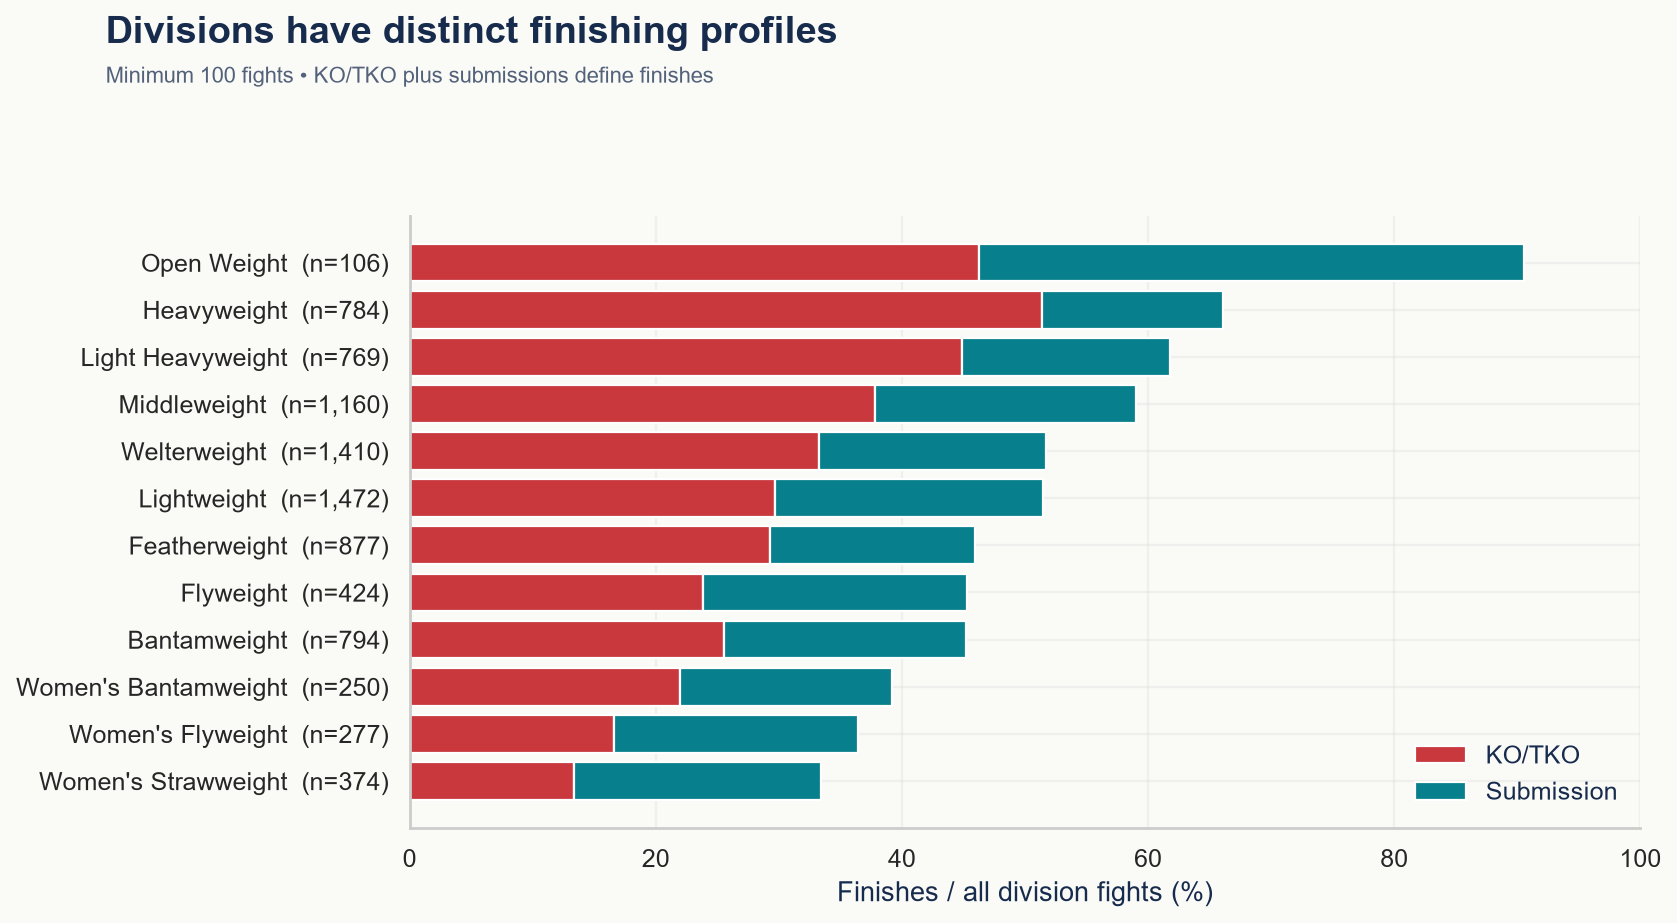

In [4]:
divisions = division_summary(fights, appearances)
display(divisions)
show(division_chart(fights, appearances))

## Age, height and reach

Use one row per fighter for height/reach correlation. Winner/loser ages are fight-level measurements and repeat athletes.

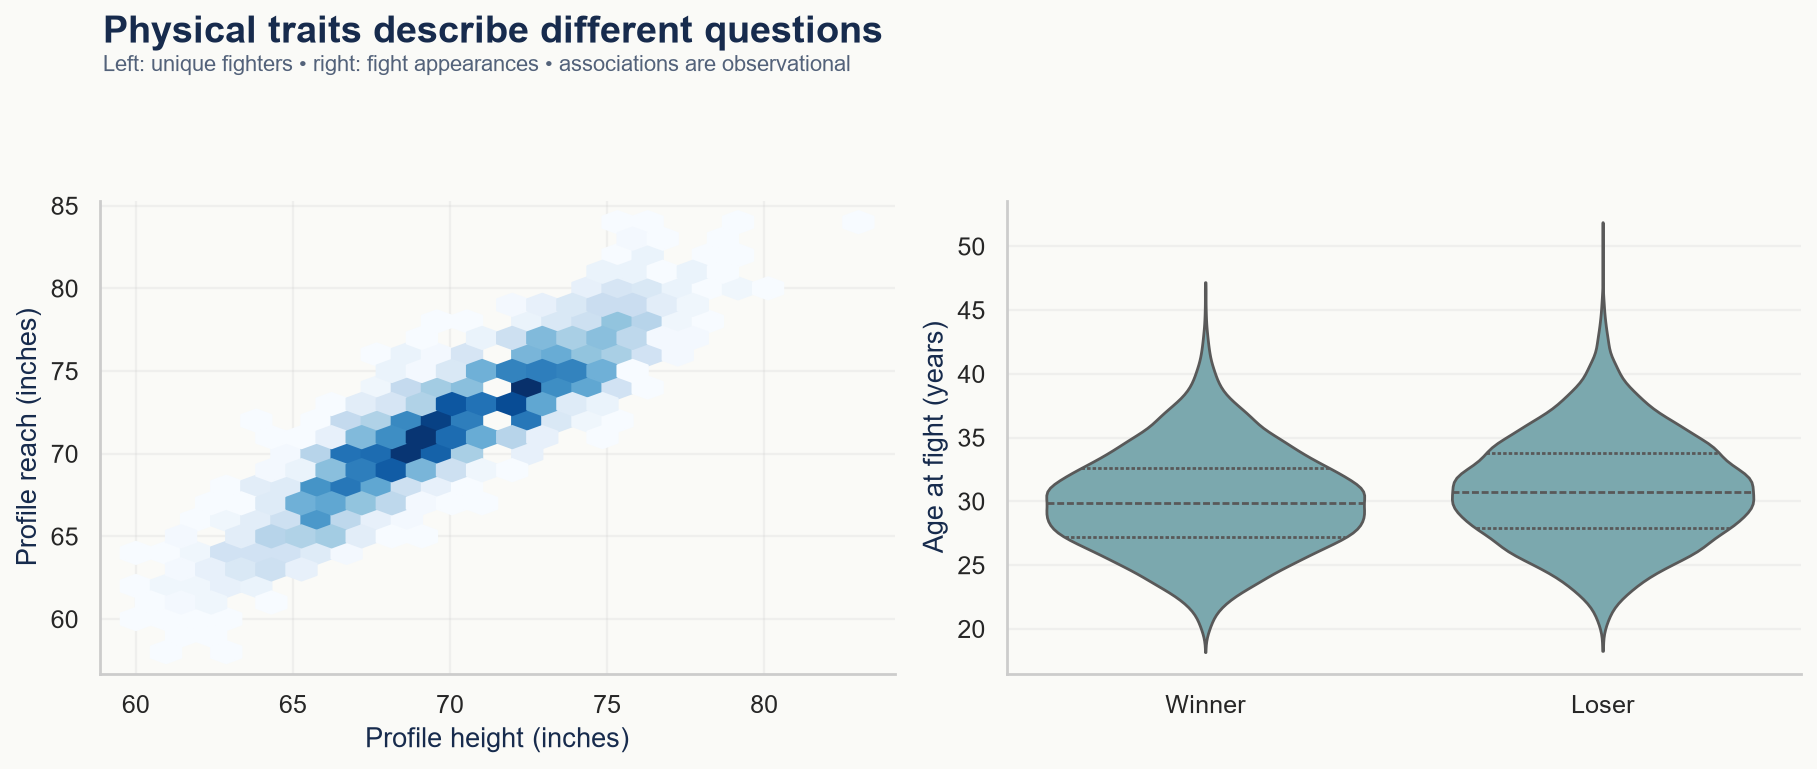

,weight_class,unequal_pairs,advantaged_win_rate,attribute
0,Bantamweight,772,0.428756,age
2,Featherweight,861,0.415796,age
3,Flyweight,417,0.414868,age
4,Heavyweight,745,0.420134,age
5,Light Heavyweight,742,0.447439,age
6,Lightweight,1424,0.400281,age
7,Middleweight,1137,0.452946,age
11,Welterweight,1381,0.439537,age
12,Women's Bantamweight,247,0.445344,age
14,Women's Flyweight,273,0.428571,age


In [5]:
show(physical_chart(appearances))
physical = pd.concat([attribute_advantage(fights, c) for c in ['age','height_inches','reach_inches']])
display(physical.query('unequal_pairs >= 100'))

## Stance and matchup outcomes

Stance is a present-day profile label, not a historical record. These associations may reflect division composition and fighter quality.

In [6]:
tables = export_fighters(data)
display(tables['stance'])
matchup = fights[fights.decisive & (((fights.r_stance == 'Southpaw') & (fights.b_stance == 'Orthodox')) | ((fights.b_stance == 'Southpaw') & (fights.r_stance == 'Orthodox')))]
southpaw_id = matchup.r_id.where(matchup.r_stance.eq('Southpaw'), matchup.b_id)
print('Southpaw vs orthodox bouts:', len(matchup))
print('Southpaw win share:', matchup.winner_id.eq(southpaw_id).mean())
display(tables['age_profile'])

,stance,appearances,fighters,wins,decisive,finish_wins,win_rate
0,Open Stance,24,6,13,24,9,0.541667
1,Orthodox,13088,2041,6358,12856,3344,0.494555
2,Sideways,6,3,2,6,2,0.333333
3,Southpaw,3406,450,1750,3344,929,0.523325
4,Switch,1017,155,525,1002,305,0.523952
5,NaN,99,80,16,96,14,0.166667


Southpaw vs orthodox bouts: 2438
Southpaw win share: 0.5332239540607056


,age_band,appearances,wins,decisive,win_rate
0,"[16, 23)",443,254,437,0.581236
1,"[23, 28)",4643,2542,4569,0.556358
2,"[28, 33)",7782,3899,7639,0.510407
3,"[33, 38)",3915,1688,3841,0.439469
4,"[38, 65)",713,246,700,0.351429


## Research extension: What do rankings, debut matchups and early careers really reveal?

The following answers are computed from the current snapshot. Tables expose denominators and missingness so the claims can be checked.

In [7]:
from src.research import run_chapter, display_answers
deep_tables, deep_answers = run_chapter('04')
display_answers(deep_answers)

### How certain are the highest win-rate rankings?

**Answer.** With a 10-decisive-fight minimum, Khabib Nurmagomedov leads at 13/13 (100.0%); the descriptive Wilson interval is 77.2%-100.0%.

**Interpretation.** The table shows how leaders change at 5, 10 and 20 fights. Intervals overlap and ignore opponent quality and athlete dependence; the ranking is not a definitive skill ordering.

### How do UFC newcomers fare against established UFC opponents?

**Answer.** In 512 decisive matchups since 2000 with exactly one newcomer and an opponent with at least five prior UFC bouts, the newcomer wins 43.2%.

**Interpretation.** Prior UFC experience is measured before the date. Newcomers may have extensive experience elsewhere, and matchmaking is selective.

### Does the age association strengthen as the age gap widens?

**Answer.** Younger-fighter win share is 52.3% for gaps up to two years and 69.2% for gaps over ten years. The four bands are monotonically increasing.

**Interpretation.** Compare the bands and their sample sizes rather than assuming a linear age effect. Equal-age and missing-DOB bouts are excluded.

### Is a successful UFC debut associated with more early opportunities?

**Answer.** Among debutants with 730 observable follow-up days, 88.4% of debut winners and 52.2% of debut losers reach three observed UFC bouts within that window.

**Interpretation.** Every entrant has the same follow-up horizon. This is observed participation, not a retention contract or causal effect; recent censored entrants and ambiguous same-day debuts are excluded.

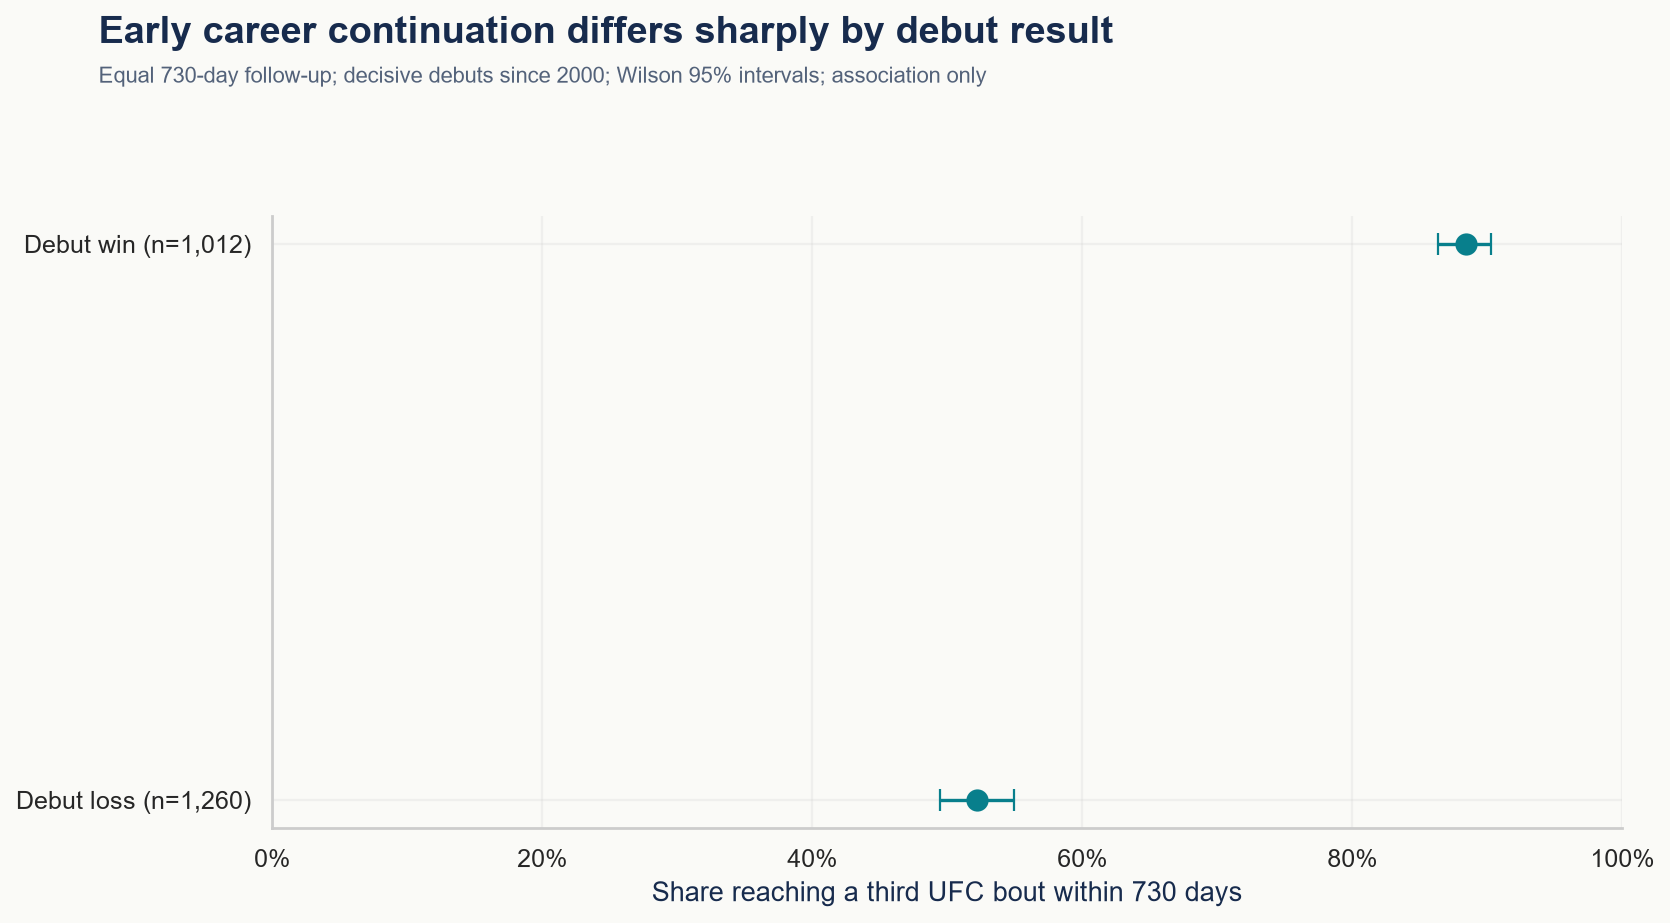

In [8]:
from src.research_visualization import research_chart
show(research_chart('04'))

In [9]:
display(deep_tables['deep_ranking_stability'])

,fighter_id,fighter_name,n,successes,rate,low,high,minimum_decisive_fights
0,032cc3922d871c7f,Khabib Nurmagomedov,13,13,1.0,0.771905,1.000000,5
1,76e2870ffafbe38f,Movsar Evloev,10,10,1.0,0.722467,1.000000,5
2,262d32ebda89efc4,Natalia Silva,8,8,1.0,0.675592,1.000000,5
3,01afe0916a40c7c5,Shavkat Rakhmonov,7,7,1.0,0.645670,1.000000,5
4,75353550928a7921,Muhammad Mokaev,7,7,1.0,0.645670,1.000000,5
5,a09ed60aa67a3f67,Farid Basharat,7,7,1.0,0.645670,1.000000,5
6,c32aeb1a59e6272d,Michael Morales,7,7,1.0,0.645670,1.000000,5
7,17734443a833cdf7,Quillan Salkilld,6,6,1.0,0.609666,1.000000,5
8,87aa9fb63d6b51a1,Zabit Magomedsharipov,6,6,1.0,0.609666,1.000000,5
9,8f765fd5775a8873,Rinat Fakhretdinov,6,6,1.0,0.609666,1.000000,5


In [10]:
display(deep_tables['deep_debut_matchups'])

,period,n,successes,rate,low,high
0,2000-2009,68,22,0.323529,0.224376,0.441555
1,2010-2019,249,108,0.433735,0.373647,0.495837
2,2020-2026,195,91,0.466667,0.397965,0.536656


In [11]:
display(deep_tables['deep_age_gap'])

,age_gap,n,successes,rate,low,high
0,"(-0.001, 2.0]",2522,1320,0.523394,0.503881,0.542836
1,"(2.0, 5.0]",3073,1717,0.558737,0.541119,0.576209
2,"(5.0, 10.0]",2445,1494,0.611043,0.591559,0.630178
3,"(10.0, 65.0]",497,344,0.692153,0.650226,0.731132


In [12]:
display(deep_tables['deep_career_continuation'])

,debut_win,n,successes,rate,low,high,mean_fights
0,False,1260,658,0.522222,0.494616,0.549693,2.920635
1,True,1012,895,0.884387,0.863217,0.902651,4.137352
